In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm

import torch
import dnnlib.util_v4 as util
from tqdm import tqdm
import pickle
from matplotlib.ticker import FuncFormatter
import pickle, types
from torch_utils import persistence

from PIL import Image

import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural_v7 import *
from plot_sim_results_v7 import *
from plot_sim_results_img_v7 import * 


import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
colorgrad = "PuOr"

# 0. Some functions...

In [2]:
def rotation_angles(points, image_coords=False):
    P = np.asarray(points, dtype=float)
    M = np.c_[P[:,0], P[:,1], np.ones(len(P))]
    s = P[:,0]**2 + P[:,1]**2
    u, *_ = np.linalg.lstsq(M, s, rcond=None)  # Kåsa least-squares circle fit
    cx, cy = u[0]/2, u[1]/2

    dx = P[:,0] - cx
    dy = P[:,1] - cy
    if image_coords:
        dy = -dy  # flip y if using image coordinates

    theta = np.arctan2(dy, dx)
    return np.mod(theta, 2*np.pi)

In [3]:
def latent_mu(latent_traj_list, encoder, dim_preserve, device, fullRes=False,
              min_var=None, rcond=None, resid_tol=1e-5, use_fp64=True):
    """
    X ≈ (L sqrt(D)) μ  ⇒  μ = D^{-1/2} L^{-1} X  (triangular) with robust fallback.
    - min_var: if None, set adaptively = max(1e-12, 1e-6 * median(D))
    - rcond:   if None, set adaptively = 1e-6 for pinv cutoff
    - resid_tol: relative residual threshold to trigger pinv path
    """
    import torch
    enc = encoder.to(device).eval()
    mu_traj, loading = [], None
    with torch.inference_mode():
        X0 = torch.from_numpy(latent_traj_list[0]).to(device=device, dtype=torch.float32)
        _, D, L = enc.encode(X0)

        d_vec = torch.diagonal(D) if D.ndim == 2 else D
        # --- adaptive thresholds ---
        mv = (max(1e-12, 1e-6 * torch.median(d_vec).item()) if min_var is None else float(min_var))
        rc = (1e-6 if rcond is None else float(rcond))

        # safe inverse sqrt
        d_safe = torch.clamp(d_vec, min=mv)
        inv_sqrt_d = d_safe.rsqrt()

        def solve_mu_batch(X):
            XT = X.T
            # optional FP64 for the solve
            if use_fp64:
                XT = XT.double(); Ld = L.double(); invsd = inv_sqrt_d.double()
            else:
                Ld = L; invsd = inv_sqrt_d
            Y = torch.linalg.solve_triangular(Ld, XT, upper=False, unitriangular=True)
            MUt = invsd.unsqueeze(1) * Y
            return MUt.T.float()  # back to fp32

        # try triangular first + residual check
        bad = False
        for arr in latent_traj_list:
            X = torch.from_numpy(arr).to(device=device, dtype=torch.float32)
            mu_full = solve_mu_batch(X)
            # residual r = ||L sqrt(D) μ - X|| / ||X||
            X_hat = (L @ torch.diag(d_safe.sqrt()) @ mu_full.T).T
            r = (X_hat - X).norm() / (X.norm() + 1e-12)
            if torch.isnan(mu_full).any() or torch.isinf(mu_full).any() or r > resid_tol:
                bad = True; break
            mu_traj.append(mu_full[:, :dim_preserve].cpu())

        # fallback: pseudoinverse with rcond
        if bad:
            loading = L @ torch.diag(d_safe.sqrt())
            if use_fp64: loading = loading.double()
            W = torch.linalg.pinv(loading, rcond=rc).float()
            mu_traj = []
            for arr in latent_traj_list:
                X = torch.from_numpy(arr).to(device=device, dtype=torch.float32)
                mu_full = (W @ X.T).T
                mu_traj.append(mu_full[:, :dim_preserve].cpu())

    if fullRes:
        return mu_traj, d_vec, L, (loading if loading is not None else L @ torch.diag(d_vec.sqrt()))
    return mu_traj

In [4]:
def hist_density_heatmap(data, bins=64, value_range=None, dims=None, density=True, log=False, per_dim_norm=False):
    X = data.reshape(len(data), -1) if data.ndim == 3 else data          # (N,784)
    if dims is None: dims = np.arange(X.shape[1])
    X = X[:, dims]
    # robust common range across dims
    if value_range is None:
        vmin, vmax = np.percentile(X, 1.0), np.percentile(X, 99.0)
    else:
        vmin, vmax = value_range
    edges = np.linspace(vmin, vmax, bins + 1)
    H = np.empty((bins, X.shape[1]), float)                                # rows: bins (low→high), cols: dims
    for j in range(X.shape[1]):
        h, _ = np.histogram(X[:, j], bins=edges, density=density)
        H[:, j] = h
    if per_dim_norm:                                                       # optional: normalize each column to [0,1]
        colmax = np.maximum(H.max(0, keepdims=True), 1e-12)
        H = H / colmax
    extent = [0, X.shape[1], edges[0], edges[-1]]
    plt.figure(figsize=(10, 4))
    im = plt.imshow(H, aspect='auto', origin='lower', extent=extent,
                    norm=LogNorm(vmin=H[H>0].min(), vmax=H.max()) if log else None)
    plt.xlabel('dimension index'); plt.ylabel('value'); plt.colorbar(im, label='hist density')
    plt.tight_layout(); 
#     plt.show()

In [5]:
def plot_ball_coordinate(trial_idx, dset_samples, T, shrink_end = 0.1):
    x2 = dset_samples[trial_idx][0:T,:,:,:].squeeze(1)
    T, H, W = x2.shape
    flat = x2.reshape(T, -1).argmax(axis=1) # [T]
    coords = np.stack([flat // W, flat % W], axis=1)
    center = np.mean(coords, axis= 0)

    T = coords.shape[0]
    t = np.arange(T)
    
    shrink = np.linspace(0.0, shrink_end, T)[:, None]
    xy = coords.astype(float) * (1.0 - shrink) + center * shrink

    plt.plot(xy[:,1], xy[:,0], linewidth=1.0, alpha=0.35)
    sc = plt.scatter(xy[:,1], xy[:,0], c=t, s=10, cmap='viridis_r')
    plt.colorbar(sc, label='time index')

    H2 = int(coords[:,0].max() + 1); W2 = int(coords[:,1].max() + 1)
    plt.xlim(-0.5, W2 - 0.5); plt.ylim(-0.5, H2 - 0.5)
    plt.gca().invert_yaxis()                            # match imshow's default origin='upper'
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title('trial ' + str(trial_idx))
    plt.tight_layout()

In [6]:
def plot_latent_coordinate(coords, title = None, shrink_end = 0.30, s = 10):
    center = np.mean(coords, axis= 0)

    T = coords.shape[0]
    t = np.arange(T)

                                   # 30% toward center by the last frame
    shrink = np.linspace(0.0, shrink_end, T)[:, None]
    xy = coords.astype(float) * (1.0 - shrink) + center * shrink

    plt.plot(xy[:,1], xy[:,0], linewidth=1.0, alpha=0.35)
    sc = plt.scatter(xy[:,1], xy[:,0], c=t, s=s, cmap='viridis_r')
    plt.colorbar(sc, label='time index')

#     H2 = int(coords[:,0].max() + 1); W2 = int(coords[:,1].max() + 1)
#     plt.xlim(-0.5, W2 - 0.5); plt.ylim(-0.5, H2 - 0.5)
    plt.gca().invert_yaxis()                            # match imshow's default origin='upper'
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(title)
    plt.tight_layout()

In [7]:
def read_model(folder, chk_pts):
    pkl_path = folder + chk_pts
    if not hasattr(persistence, "_orig_reconstruct"):
        persistence._orig_reconstruct = persistence._reconstruct_persistent_obj
    def _tolerant_reconstruct(meta):
        try:
            return persistence._orig_reconstruct(meta)
        except Exception:
            class _Stub: pass
            return _Stub()

    class PatchedUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if module == "torch_utils.persistence" and name == "_reconstruct_persistent_obj":
                return _tolerant_reconstruct
            return super().find_class(module, name)

    with open(pkl_path, "rb") as f:
        model_all = PatchedUnpickler(f).load()

    net = model_all["ema"] if "ema" in model_all else model_all["net"]
    flow_net = net.unet_model  # Compressive flow (u_theta)
    dyn_net = net.vnet_model   # Dynamics flow (v_theta)
    encoder = net.encoder
    lag = infer_lag_k_from_dyn_net(dyn_net)
    return flow_net, dyn_net, encoder, lag

In [8]:
def plot_tau(T, out_imgs_tau, dset_samples, trial_idx, tau, title = None):
    plot_frame(dset_samples, T, trial_idx)
    plt.suptitle('true, trial = ' + str(trial_idx))
    plt.tight_layout()
    plot_frame(out_imgs_tau, T, trial_idx)
    if title is None:
        plt.suptitle('simulated- tau = ' + str(tau))
    else:
        plt.suptitle(title)
    plt.tight_layout()

In [9]:
def get_mu_from_encoder(encoder, data_flattent, dim_to_keep, trial_idx):
    encoder = encoder.to(device).eval()
    with torch.inference_mode():
        X0 = torch.from_numpy(data_flattent[trial_idx]).to(device=device, dtype=torch.float32)
        mu_data, D, L = encoder.encode(X0)
        mu_keep = mu_data[:,0:dim_to_keep]
    return mu_keep.detach().cpu().numpy()

In [10]:
def get_mu_from_encoder(encoder, data_flattent, dim_to_keep, trial_idx=None):
    import numpy as np
    encoder = encoder.to(device).eval()
    with torch.inference_mode():
        # normalize indices
        if trial_idx is None or trial_idx == 'all':
            indices = range(len(data_flattent))
        elif isinstance(trial_idx, slice):
            indices = range(len(data_flattent))[trial_idx]
        elif np.isscalar(trial_idx):
            indices = [int(trial_idx)]
        else:  # list/tuple/array
            indices = list(trial_idx)

        outs = []
        for idx in indices:
            X0 = torch.from_numpy(data_flattent[idx]).to(device=device, dtype=torch.float32)
            mu_data, D, L = encoder.encode(X0)
            outs.append(mu_data[:, :dim_to_keep].detach().cpu().numpy())

    return np.concatenate(outs, axis=0)  # shape: (sum T_i, dim_to_keep)

In [11]:
def plot_latent_2d(ax, xy, norm, title=""):
    t = np.arange(len(xy))
    segs = np.stack([xy[:-1], xy[1:]], axis=1)      # (T-1, 2, 2)

    lc = LineCollection(segs, cmap='viridis', norm=norm, linewidth=2)
    lc.set_array(t[1:])                             
    ax.add_collection(lc)
    ax.autoscale()
    ax.margins(0.05)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title(title)
    return lc

In [12]:
def snap_shot_plot(xys, titles, trial_idx):
    t_max = max(len(xy) for xy in xys) - 1
    norm  = Normalize(vmin=0, vmax=t_max)
    fig, axs = plt.subplots(2, 2, figsize=(8, 8))
    for ax, xy, ttl in zip(axs.ravel(), xys, titles):
        plot_latent_2d(ax, xy, norm, ttl)
    fig.subplots_adjust(right=0.88)
    sm = ScalarMappable(cmap='viridis', norm=norm); sm.set_array([])
    cax = fig.add_axes([0.90, 0.15, 0.02, 0.70])     # [left, bottom, width, height]
    fig.colorbar(sm, cax=cax, label='time index')
    fig.suptitle("Latent trajectories for different Losses, trial = " + str(trial_idx), fontsize=13)
#     plt.tight_layout()
    plt.show()

In [13]:
def recon_check_x0(encoder, trial_check, T_check, dset_samples):
    encoder = encoder.to(device).eval()
    X1_ori = dset_samples[trial_check][T_check,0,:,:]
    data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
    with torch.inference_mode():
        X1 = torch.from_numpy(data_flattent[trial_check][T_check,:]).to(device=device, dtype=torch.float32)
        X0 = encoder.rsample(X1)
    X0_back = X0.reshape(X0.shape[0], C, H, W)
    return X0_back[0,0,:,:].detach().cpu().numpy()

In [14]:
# def mu_velocity_field(encoder, dyn_net, X, K, tau, h=1e-3):
#     # dtype/device hygiene
#     if X.dtype != torch.float32:
#         X = X.to(dtype=torch.float32)
#     device = X.device
#     N, D = X.shape

#     # time tensor
#     if torch.is_tensor(tau):
#         t = tau.reshape(-1).to(device=device, dtype=X.dtype)
#         if t.numel() == 1:
#             t = t.expand(N)
#     else:
#         t = torch.full((N,), float(tau), device=device, dtype=X.dtype)

#     # covariates: for lag-0, pass starting point as static covariate
#     cov_static = X                                 # (N, D)
#     dim_cd = int(getattr(dyn_net, "dim_cov_dynamic", 0) or 0)
#     cov_dynamic = torch.zeros((N, dim_cd), device=device, dtype=X.dtype) if dim_cd > 0 else None

#     # eval guard
#     enc_was_train, dyn_was_train = encoder.training, dyn_net.training
#     encoder.eval(); dyn_net.eval()
#     try:
#         mu0, _, _ = encoder.encode(X)              # (N, D)

#         # Call pattern: try 6-arg (with t_dyn), else 5-arg
#         try:
#             vX = dyn_net(X, None, cov_dynamic, cov_static, t, t)   # (N, D)
#         except TypeError:
#             vX = dyn_net(X, None, cov_dynamic, cov_static, t)      # (N, D)

#         mu1, _, _ = encoder.encode(X + h * vX)     # (N, D)
#     finally:
#         encoder.train(enc_was_train); dyn_net.train(dyn_was_train)

#     mK = mu0[:, :K].contiguous()
#     uK = (mu1[:, :K] - mK) / h
#     return mK, uK

@torch.no_grad()
def mu_velocity_field_tau0_from_compression(encoder, dyn_net, flow_net,
                                            X1_flat, K, H, W, C=1):
    device = X1_flat.device
    X1_flat = X1_flat.to(torch.float32)
    N, D = X1_flat.shape

    # (B,D)->(B,D) adapter for flow if needed
    class _FlatAdapter(torch.nn.Module):
        def __init__(self, net): super().__init__(); self.net = net.eval()
        def forward(self, x_flat, tau):
            B = x_flat.shape[0]
            x_img = x_flat.view(B, C, H, W)
            out   = self.net(x_img, tau)
            return out.view(B, -1)

    try:
        tprobe = flow_net(torch.zeros((1, D), device=device, dtype=X1_flat.dtype),
                          torch.tensor([1.0], device=device, dtype=X1_flat.dtype))
        flow_for_ode = flow_net if (tprobe.dim()==2 and tprobe.shape[1]==D) else _FlatAdapter(flow_net).to(device).eval()
    except Exception:
        flow_for_ode = _FlatAdapter(flow_net).to(device).eval()

    # times / modes
    t0 = torch.zeros((N,), device=device, dtype=X1_flat.dtype)
    enc_mode, dyn_mode = encoder.training, dyn_net.training
    encoder.eval(); dyn_net.eval()
    try:
        # 1) compress X1 -> X0 (τ: 1 -> 0)
        X0 = util.calc_flow_trajectories(flow_for_ode, X1_flat, 1.0, 0.0, nt=2)[-1]   # (N,D)

        # 2) read D,L once; prepare top-K inverse head
        _, Dmat, Lmat = encoder.encode(X0[:1])
        d_vec  = torch.diagonal(Dmat) if Dmat.ndim==2 else Dmat
        d_safe = torch.clamp(d_vec, min=max(1e-12, 1e-6 * torch.median(d_vec).item()))
        inv_sqrt_dK = d_safe[:K].rsqrt()                   # (K,)
        LK = Lmat[:K, :K]                                  # (K,K)

        def B_topK_apply(Xflat):                           # returns (N,K)
            XK = Xflat[:, :K].T                            # (K,N)
            Y  = torch.linalg.solve_triangular(LK, XK, upper=False, unitriangular=True)  # (K,N)
            MUt = inv_sqrt_dK.unsqueeze(1) * Y            # (K,N)
            return MUt.T.contiguous()                      # (N,K)

        # μ(X0)
        mK = B_topK_apply(X0)

        # 3) v0 at τ=0: xt_tau=X0, cov_static=X1 (lag-0)
        dim_cd = int(getattr(dyn_net, "dim_cov_dynamic", 0) or 0)
        cov_dynamic = torch.zeros((N, dim_cd), device=device, dtype=X1_flat.dtype) if dim_cd>0 else None
        try:
            v0 = dyn_net(X0, None, cov_dynamic, X1_flat, t0, t0)   # (N,D)
        except TypeError:
            v0 = dyn_net(X0, None, cov_dynamic, X1_flat, t0)

        # u = B_topK v0
        uK = B_topK_apply(v0)

    finally:
        encoder.train(enc_mode); dyn_net.train(dyn_mode)

    return mK, uK

In [15]:
def plot_v_in_mu(muK_np, uK_np, arrow_len = None, arrow_width = 0.005, title = 'v in mu'):
    x, y = muK_np[:,0], muK_np[:,1]
    u, v = uK_np[:,0],  uK_np[:,1]
    spd   = np.hypot(u, v)
    
    # unit direction (zero-safe)
    ux = np.divide(u, spd, out=np.zeros_like(u), where=spd>0)
    uy = np.divide(v, spd, out=np.zeros_like(v), where=spd>0)
    
    # natural limits + light padding (no square forcing of ranges)
    xmin, xmax = x.min(), x.max(); sx = xmax - xmin
    ymin, ymax = y.min(), y.max(); sy = ymax - ymin
    padx, pady = 0.05*sx, 0.05*sy
    xlo, xhi = xmin - padx, xmax + padx
    ylo, yhi = ymin - pady, ymax + pady
    
    L = (0.05 * max(1e-12, min(sx, sy))) if (arrow_len is None) else float(arrow_len)
    
    dx, dy = L * ux, L * uy    # ALL arrows same length L
    
    plt.figure(figsize=(7,7))
    plt.scatter(x, y, s=2, c='k', alpha=0.10, zorder=1)
    Q = plt.quiver(x, y, dx, dy, spd,    # color = speed
                   angles='xy', scale_units='xy', scale=1.0,
                   pivot='tail', width=arrow_width, cmap='viridis', zorder=2)
    plt.colorbar(Q, label='|velocity|')
    
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')  # true on-screen lengths
    ax.set_box_aspect(1)                      # square-looking axes box
    ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi)
    plt.xlabel(r'$\mu_1$'); plt.ylabel(r'$\mu_2$')
    plt.title(title)
    plt.tight_layout()

# 1. Read Data

In [16]:
folder_data = 'out/ball/no_t/data'
useCov = False

dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
cov_static_samples = np.load(folder_data + "/cov_static_trunc_only.npz", allow_pickle=True)
dset_samples = to_list_of_arrays(dataset_samples['samples'])
cov_stat_samples = to_list_of_arrays(cov_static_samples['samples'])

In [17]:
is_image = (np.asarray(dset_samples[0]).ndim == 4)
if is_image:
    _, C, H, W = np.asarray(dset_samples[0]).shape
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)

In [18]:
np.asarray(dset_samples[0]).shape

(50, 1, 28, 28)

In [19]:
eps = 1e-2
padded = [np.pad(a, ((0, T_max-a.shape[0]), (0,0), (0,0), (0,0)), mode='constant', constant_values=np.nan)
          for a in dset_samples]                                              # -> (n_trial, T_max, C, H, W)
stacked = np.stack(padded, axis=0)
min_img = np.nanmin(stacked, axis=(0,1))                                      # shape (C,H,W)
max_img = np.nanmax(stacked, axis=(0,1))                                      # shape (C,H,W)
clamp_range = np.stack([min_img - eps, max_img + eps], axis=0).astype(np.float32)  # shape (2,C,H,W)

## 1.1 Plot Data

In [20]:
TRIAL_IDX = 0

/home/ganchao/Desktop/Velocity_Flow_Matching-global_new_param_new_pt/plot_sim_results_img_v7.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1681896/2731345241.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


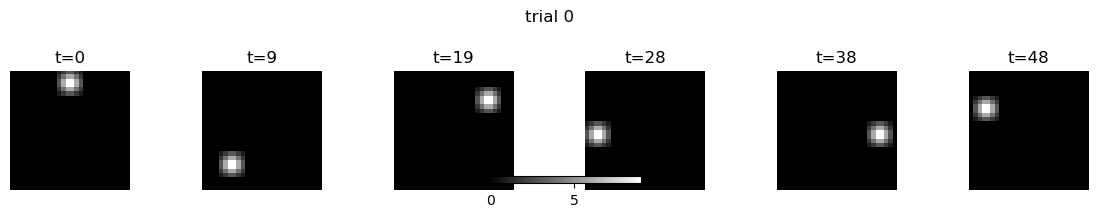

In [21]:
T = T_max
sig = 1e-1
dset_samples_noise = [a + np.random.randn(*a.shape)*sig for a in dset_samples]

plot_frame(dset_samples, T, TRIAL_IDX)
plt.suptitle('trial ' + str(TRIAL_IDX))
plt.tight_layout()

In [22]:
# plot_frame(dset_samples_noise, T, TRIAL_IDX)
# plt.suptitle('noised, trial ' + str(TRIAL_IDX))
# plt.tight_layout()

In [23]:
data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]

data_flattent_all = np.concatenate(data_flattent, axis=0)
data_flattent_all_noise = data_flattent_all + np.random.randn(*data_flattent_all.shape)*sig

In [24]:
# hist_density_heatmap(data_flattent_all, bins=(28*28)//10, density = False, value_range = [1, 6])
# plt.title('histogram count of flattened data, drop values < 1 (black background)');

In [25]:
# hist_density_heatmap(data_flattent_all_noise, bins=(28*28)//10, density = False, value_range = [1, 6])
# plt.title('histogram count of NOISED flattened data, drop values < 1 (black background)');

## 1.2 Plot Coordinates

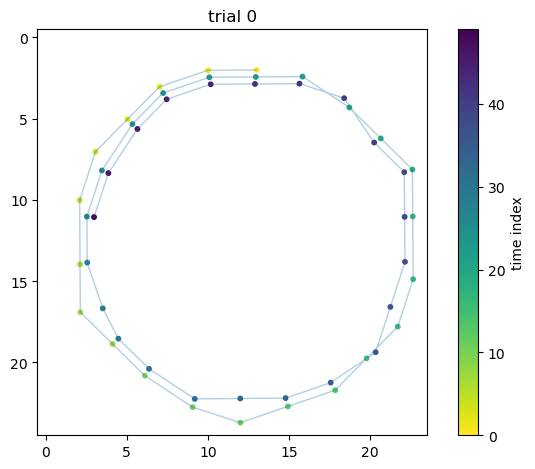

In [26]:
T = T_max
plot_ball_coordinate(TRIAL_IDX, dset_samples, T)

# 2. Read Models

In [27]:
folder = 'out/ball/no_t/00000-ball_dim3_lag0_not-prr-uncond-regularFM-gpus1-batch256-fp32'
flow_net1, dyn_net1, encoder1, lag = read_model(folder, '/network-snapshot-000502-pretrain.pkl')
flow_net2, dyn_net2, encoder2, _ = read_model(folder, '/network-snapshot-002672-pretrain.pkl')
flow_net3, dyn_net3, encoder3, _ = read_model(folder, '/network-snapshot-002724-pretrain.pkl')
flow_net4, dyn_net4, encoder4, _ = read_model(folder, '/network-snapshot-043008.pkl')

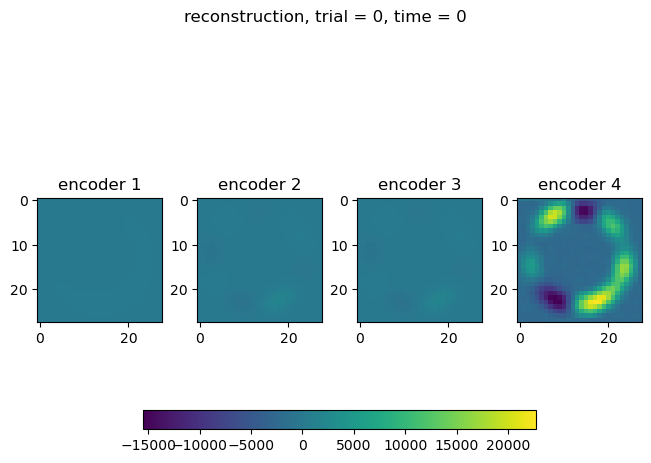

In [28]:
# check reconstruction
trial_check = 0
T_check = 0

X0_back1 = recon_check_x0(encoder1, trial_check, T_check, dset_samples = dset_samples)
X0_back2 = recon_check_x0(encoder2, trial_check, T_check, dset_samples = dset_samples)
X0_back3 = recon_check_x0(encoder3, trial_check, T_check, dset_samples = dset_samples)
X0_back4 = recon_check_x0(encoder4, trial_check, T_check, dset_samples = dset_samples)

fig, axs = plt.subplots(1, 4, constrained_layout=True)
arrs = [X0_back1, X0_back2, X0_back3, X0_back4]
vmin = min(np.min(a) for a in arrs); vmax = max(np.max(a) for a in arrs)
im = axs[0].imshow(X0_back1, vmin=vmin, vmax=vmax); axs[0].set_title('encoder 1')
axs[1].imshow(X0_back2, vmin=vmin, vmax=vmax);       axs[1].set_title('encoder 2')
axs[2].imshow(X0_back3, vmin=vmin, vmax=vmax);       axs[2].set_title('encoder 3')
axs[3].imshow(X0_back4, vmin=vmin, vmax=vmax);       axs[3].set_title('encoder 4')
fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.06, pad=0.18)
fig.suptitle(f"reconstruction, trial = {trial_check}, time = {T_check}", y=0.96)
plt.show()

# 3. Simulate Trajectories

In [29]:
TRIAL_IDX = 0

In [30]:
n_step = T_max

## 3.1 Data space (tau = 1.0)

In [31]:
tau = 1.0
traj_sim_tau1_flattent, lag_cov_list = generate_traj_image_onthefly(dyn_net4.to(device),
                                                                    dset_samples, n_step,
                                                                    tau, device, lag,
                                                                    include_x0_tau=False,
                                                                    oracle=False,
                                                                    flow_net=None,
                                                                    clamp_range=clamp_range
                                                                    )

100%|███████████████████████████████████████████| 49/49 [00:01<00:00, 27.12it/s]


In [32]:
out_imgs_tau1 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau1_flattent]

/tmp/ipykernel_1681896/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1681896/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


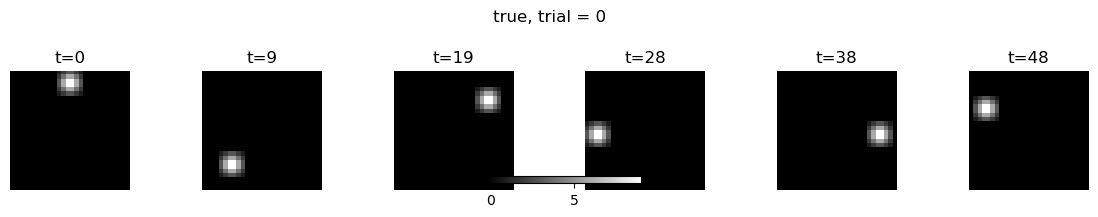

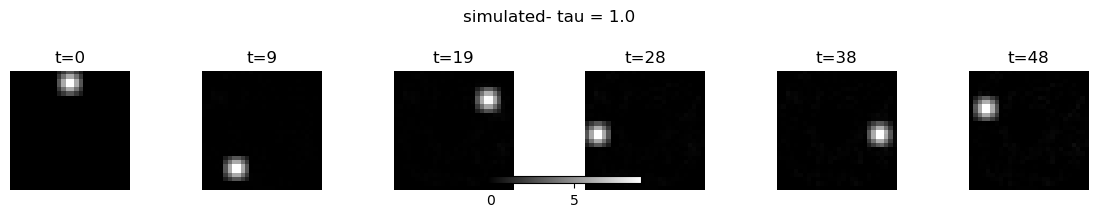

In [33]:
plot_tau(n_step, out_imgs_tau1, dset_samples, trial_idx = TRIAL_IDX, tau = 1.0)

In [34]:
# # need to be updated
# C, H, W = np.asarray(dset_samples[TRIAL_IDX][0]).shape 
# X1 = torch.from_numpy(data_flattent[TRIAL_IDX]).to(device=device, dtype=torch.float32)

# mK, uK = mu_velocity_field_tau0_from_compression(
#     encoder4.to(device), dyn_net4.to(device), flow_net4.to(device),
#     X1, K=2, H=H, W=W, C=C
# )
# muK_np = mK.cpu().numpy()
# uK_np  = uK.cpu().numpy()
# plot_v_in_mu(muK_np, uK_np, arrow_len = None, arrow_width = 0.01, title = 'v in mu')

## 3.2 Latent space (tau = 0.0)

In [35]:
out_imgs_tau0_flow_flatten = proj_to_latent(out_imgs_tau1, flow_net4.to(device), 0.0, device)
out_imgs_tau0_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in out_imgs_tau0_flow_flatten ]

In [36]:
tau = 0.0
traj_sim_tau0_flattent, _ = generate_traj_image_onthefly(dyn_net4.to(device),
                                                         dset_samples, n_step,
                                                         tau, device, lag,
                                                         include_x0_tau=False,
                                                         oracle=False,
                                                         flow_net=flow_net4.to(device),
                                                         clamp_range=clamp_range
                                                         )
out_imgs_tau0 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau0_flattent ]

100%|███████████████████████████████████████████| 49/49 [00:01<00:00, 26.89it/s]


/tmp/ipykernel_1681896/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1681896/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


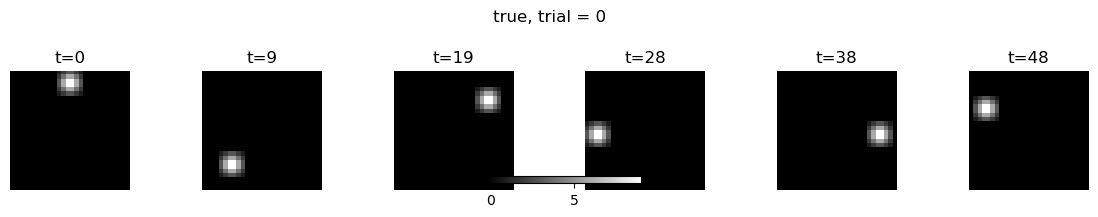

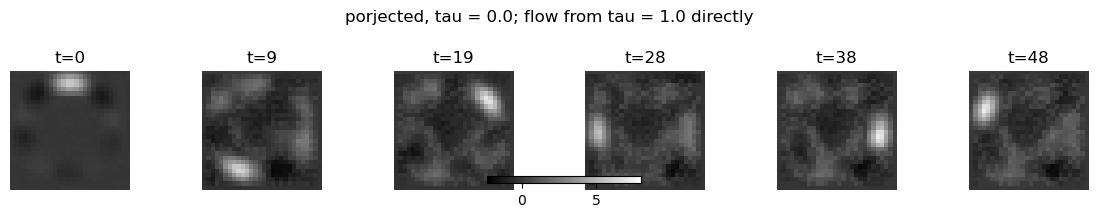

In [37]:
plot_tau(T, out_imgs_tau0_flow, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'porjected, tau = 0.0; flow from tau = 1.0 directly')

/tmp/ipykernel_1681896/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1681896/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


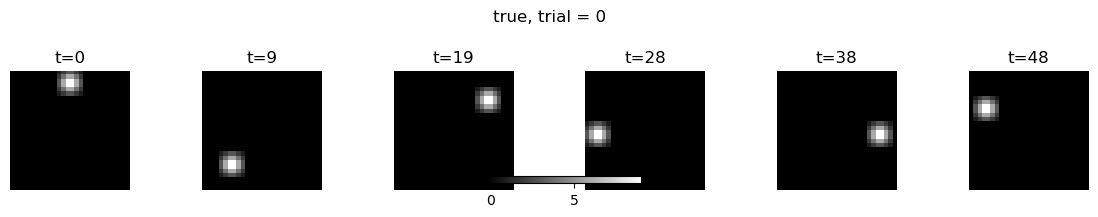

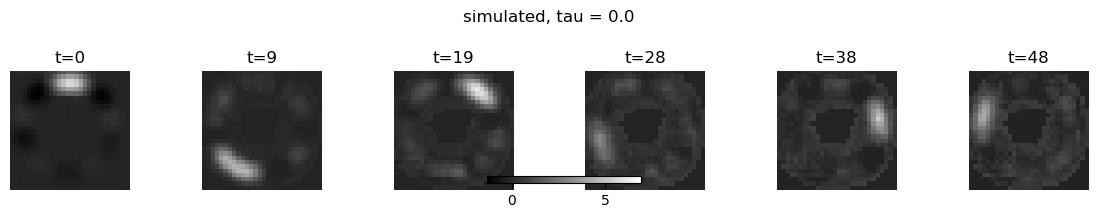

In [38]:
plot_tau(T, out_imgs_tau0, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0')

# 4. Latent space

In [41]:
# folder = 'out/ball/no_t/00000-ball_dim3_lag0_not-prr-uncond-regularFM-gpus1-batch256-fp32'
# flow_net4, dyn_net4, encoder4, _ = read_model(folder, '/network-snapshot-000051-pretrain.pkl')

In [42]:
data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]

## 4.1 directly from encoder: mu(x_data)

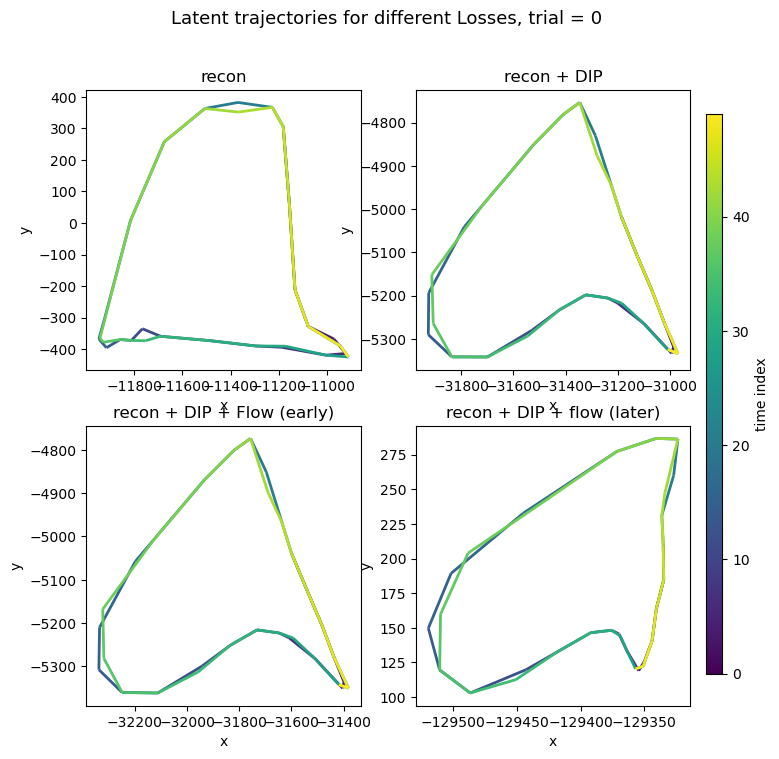

In [43]:
dim_to_keep = 2
mu_keep1 = get_mu_from_encoder(encoder1, data_flattent, dim_to_keep, TRIAL_IDX)
mu_keep2 = get_mu_from_encoder(encoder2, data_flattent, dim_to_keep, TRIAL_IDX)
mu_keep3 = get_mu_from_encoder(encoder3, data_flattent, dim_to_keep, TRIAL_IDX)
mu_keep4 = get_mu_from_encoder(encoder4, data_flattent, dim_to_keep, TRIAL_IDX)
xys     = [mu_keep1, mu_keep2, mu_keep3, mu_keep4]
titles  = ['recon', 'recon + DIP', 'recon + DIP + Lie', 'recon + DIP + Lie + flow']
titles  = ['recon', 'recon + DIP', 'recon + DIP + Flow (early)', 'recon + DIP + flow (later)']
snap_shot_plot(xys, titles, TRIAL_IDX)

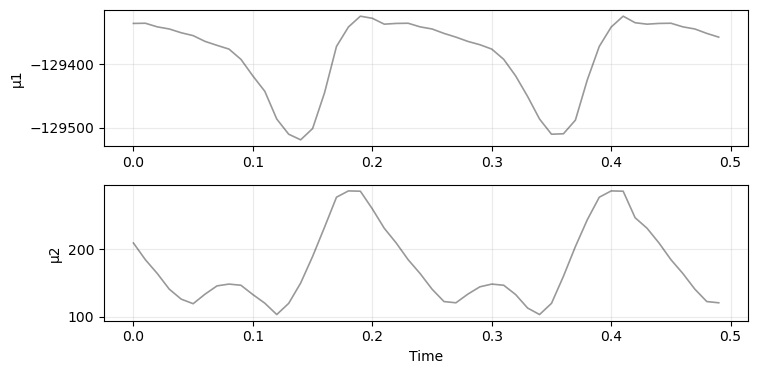

In [44]:
plot_latent_time_series([mu_keep4], alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)

## 4.2 flowed/ project

In [45]:
latent_traj_list = proj_to_latent(dset_samples, flow_net4.to(device), 0.0, device)
mu_traj_sim, d, L, loading = latent_mu(latent_traj_list, encoder4.to(device), dim_to_keep, device, fullRes = True)

In [46]:
Z_dims_to_keep = (loading[0:dim_to_keep,0:dim_to_keep].detach().cpu().numpy() @ mu_keep4.T).T
L_np = L.detach().cpu().numpy()
d_np = d.detach().cpu().numpy()
mu_all = get_mu_from_encoder(encoder4, data_flattent, 784, TRIAL_IDX)

np.savetxt("L.csv", L_np, delimiter=",")
np.savetxt("d.csv", d_np, delimiter=",")
np.savetxt("mu.csv", mu_all, delimiter=",")

In [47]:
d_np[0:60]

array([4.67985863e-08, 5.86048330e-08, 9.84123076e-08, 9.22405619e-08,
       1.62655581e-07, 1.13028534e-07, 1.38891110e-07, 1.58324227e-07,
       1.24742328e-07, 7.11338828e-08, 3.10493711e-08, 3.15336948e-08,
       3.63786268e-09, 4.15753432e-09, 1.67094094e-09, 4.00006162e-09,
       3.34470851e-09, 5.88429305e-09, 5.43863665e-09, 4.31707070e-09,
       3.86493593e-09, 4.91447638e-09, 5.68938896e-09, 5.46759260e-09,
       4.61855532e-09, 4.70342698e-09, 5.32107824e-09, 6.01142780e-09,
       5.92276850e-09, 6.21840801e-09, 6.01603878e-09, 6.04397554e-09,
       6.12052897e-09, 6.08604811e-09, 6.11659612e-09, 6.10139050e-09,
       6.10979844e-09, 6.10979844e-09, 6.10979844e-09, 6.10979844e-09,
       6.10979844e-09, 6.10979844e-09, 6.10979844e-09, 6.10979844e-09,
       6.10979844e-09, 6.10979844e-09, 6.10979844e-09, 6.10979844e-09,
       6.10979844e-09, 6.10979844e-09, 9.99999195e-10, 9.99999195e-10,
       9.99999195e-10, 9.99999195e-10, 9.99999195e-10, 9.99999195e-10,
      

In [48]:
torch.norm(loading[:,0:10], dim= 0)

tensor([0.5531, 0.4498, 0.5191, 0.4339, 0.4919, 0.4089, 0.4580, 0.4317, 0.4003,
        0.3635], device='cuda:0', dtype=torch.float64)

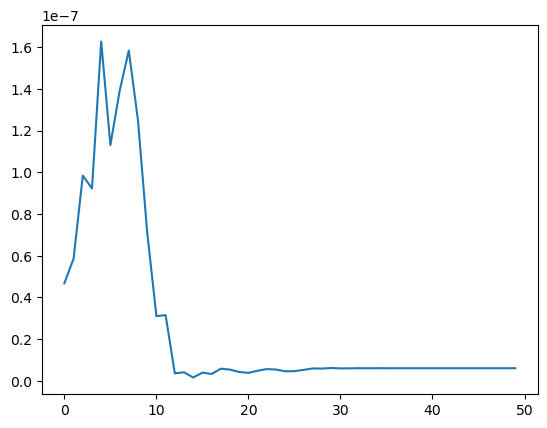

In [49]:
plt.plot(d_np[0:50])

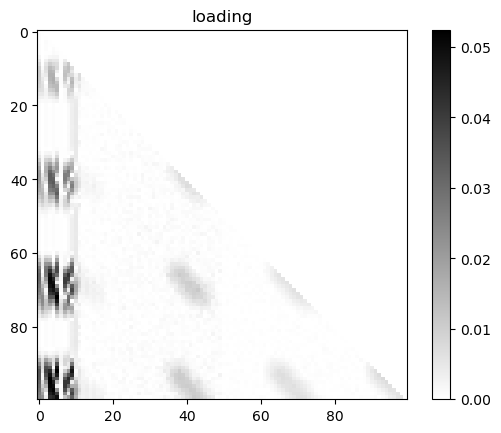

In [50]:
idx_show = 100
plt.imshow(np.abs(loading[0:idx_show,0:idx_show].detach().cpu().numpy()), cmap = 'gray_r')
plt.title('loading')
plt.colorbar()

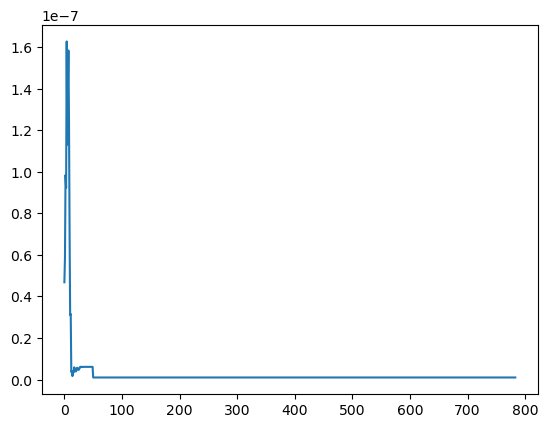

In [51]:
plt.plot(d_np)

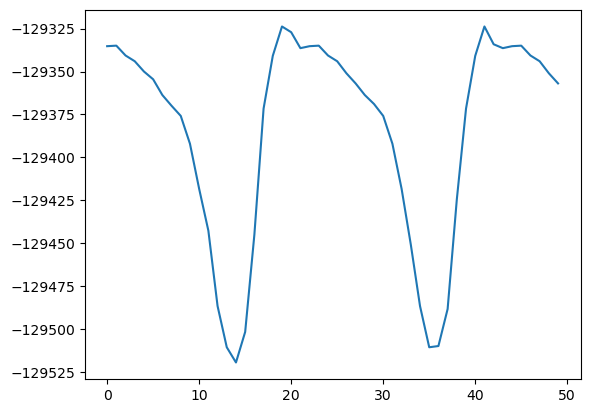

In [52]:
plt.plot(mu_all[:,0]);

In [53]:
mu_all[:,0]

array([-129335.2  , -129334.89 , -129340.625, -129343.98 , -129349.96 ,
       -129354.5  , -129363.664, -129369.92 , -129375.83 , -129392.05 ,
       -129418.34 , -129442.7  , -129486.61 , -129510.625, -129519.49 ,
       -129501.69 , -129445.   , -129371.58 , -129340.836, -129323.72 ,
       -129327.06 , -129336.35 , -129335.2  , -129334.89 , -129340.625,
       -129343.98 , -129350.984, -129356.89 , -129363.664, -129368.88 ,
       -129375.83 , -129392.05 , -129418.34 , -129450.836, -129486.61 ,
       -129510.625, -129509.91 , -129488.336, -129424.44 , -129371.58 ,
       -129340.836, -129323.72 , -129334.08 , -129336.35 , -129335.2  ,
       -129334.89 , -129340.625, -129343.98 , -129350.984, -129356.89 ],
      dtype=float32)

In [54]:
np.savetxt('mu.csv', mu_all, delimiter=',')

In [55]:
L_np = L.detach().cpu().numpy()
d_np = d.detach().cpu().numpy()
mu_all = get_mu_from_encoder(encoder4, data_flattent, 784, TRIAL_IDX)

In [56]:
loading_np = loading.detach().cpu().numpy()

In [57]:
mu_all.shape

(50, 784)

In [58]:
loading_np.shape

(784, 784)

In [59]:
def mu_group_recon(loading_np: np.ndarray,
                   mu_all: np.ndarray,
                   mu_idx=None,             # int | list[int] | np.ndarray | slice | None
                   H: int = 28,
                   W: int = 28,
                   mean_img: np.ndarray = None,
                   clip=None):
    D = loading_np.shape[0]
    assert loading_np.ndim == 2 and loading_np.shape[1] == D
    N, D2 = mu_all.shape
    assert D2 == D and H * W == D

    # normalize mu_idx to an integer index array
    if mu_idx is None:
        idx = np.arange(D)
    elif isinstance(mu_idx, slice):
        idx = np.arange(D)[mu_idx]
    else:
        arr = np.asarray(mu_idx)
        if arr.dtype == bool:
            idx = np.flatnonzero(arr)
        else:
            idx = arr.astype(int, copy=False).ravel()

    A_sub  = loading_np[:, idx]     # (D, K)
    mu_sub = mu_all[:, idx]         # (N, K)
    recon_flat = mu_sub @ A_sub.T   # (N, D)

    if mean_img is not None:
        mean_flat = mean_img.reshape(-1)
        assert mean_flat.size == D
        recon_flat = recon_flat + mean_flat

    recon = recon_flat.reshape(N, H, W)
    if clip is not None:
        lo, hi = clip
        recon = np.clip(recon, lo, hi)
    return recon

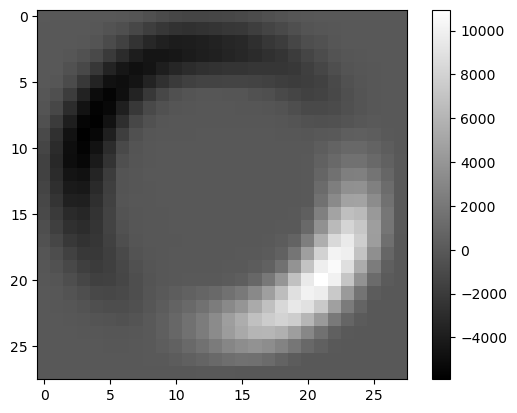

In [60]:
rec = mu_group_recon(loading_np, mu_all, np.arange(1), H = 28, W = 28)
ball_idx = 30
plt.imshow(rec[ball_idx], cmap = 'gray')
plt.colorbar()

In [61]:
# x2 = dset_samples[TRIAL_IDX][:,:,:,:].squeeze(1)
# T, H, W = x2.shape
# flat = x2.reshape(T, -1).argmax(axis=1) # [T]
# coords = np.stack([flat // W, flat % W], axis=1)
# angles = rotation_angles(coords)
# plt.scatter(mu_all[:,0], mu_all[:,1], c = angles)

/tmp/ipykernel_1681896/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1681896/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


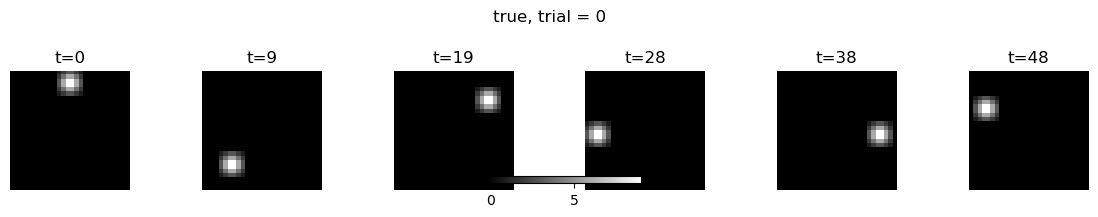

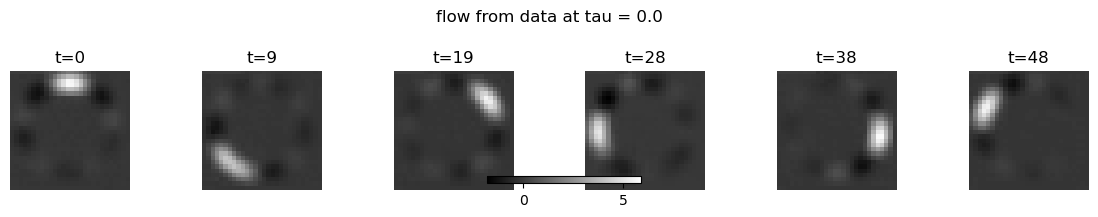

In [62]:
data_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in latent_traj_list ]
plot_tau(T, data_flow, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'flow from data at tau = 0.0')

In [63]:
mu_traj_flow_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
# plot_latent_time_series(mu_traj_flow_np, alpha = 0.4, dims=np.arange(dim_to_keep), 
#                         dt=0.01, labels=None)
# plt.suptitle('flowed latent trajc for each trial')

In [65]:
# fig, axs = plt.subplots()
# norm  = Normalize(vmin=0, vmax=T_max)
# plot_latent_2d(axs, mu_traj_flow_np[TRIAL_IDX], norm, 'flowed, trial = ' + str(TRIAL_IDX))

In [66]:
# plot_latent_coordinate(mu_traj_flow_np[TRIAL_IDX], title = None, shrink_end = 0.30)
# plt.title('flowed, trial = ' + str(TRIAL_IDX))

## 4.3 simulated

In [67]:
dim_to_keep = 2
# data_flattent
mu_traj_sim, d, L, loading = latent_mu(traj_sim_tau0_flattent, encoder4.to(device), dim_to_keep, device, fullRes = True)

In [68]:
d[0:10]

tensor([4.6799e-08, 5.8605e-08, 9.8412e-08, 9.2241e-08, 1.6266e-07, 1.1303e-07,
        1.3889e-07, 1.5832e-07, 1.2474e-07, 7.1134e-08], device='cuda:0')

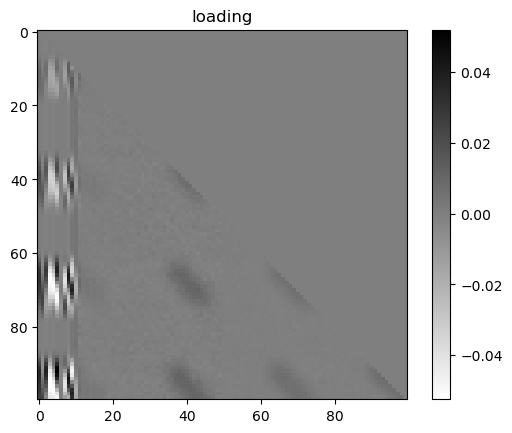

In [69]:
idx_show = 100
plt.imshow(loading[0:idx_show,0:idx_show].detach().cpu().numpy(), cmap = 'gray_r')
plt.title('loading')
plt.colorbar()

In [70]:
mu_traj_sim_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
# mu_traj_sim_np_plot = [mu_traj_sim_np[ii][10:,:] for ii in range(len(mu_traj_sim_np))]
# plot_latent_time_series(mu_traj_sim_np_plot, alpha = 0.4, dims=np.arange(dim_to_keep), 
#                         dt=0.01, labels=None)
# plt.suptitle('simulated latent trajc for each trial')

In [72]:
# fig, axs = plt.subplots()
# norm  = Normalize(vmin=0, vmax=T_max)
# plot_latent_2d(axs, mu_traj_sim_np[TRIAL_IDX], norm, 'simulated, trial = ' + str(TRIAL_IDX))

# Appendix: put all plots together

In [73]:
len(dset_samples)

10

In [74]:
TRIAL_IDX = 9

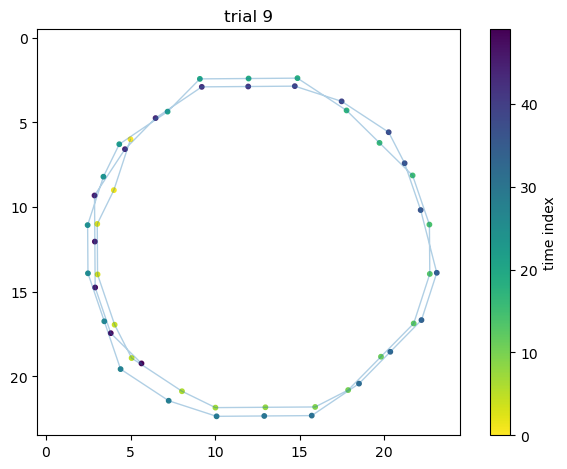

In [75]:
T = T_max
plot_ball_coordinate(TRIAL_IDX, dset_samples, T)

/tmp/ipykernel_1681896/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1681896/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


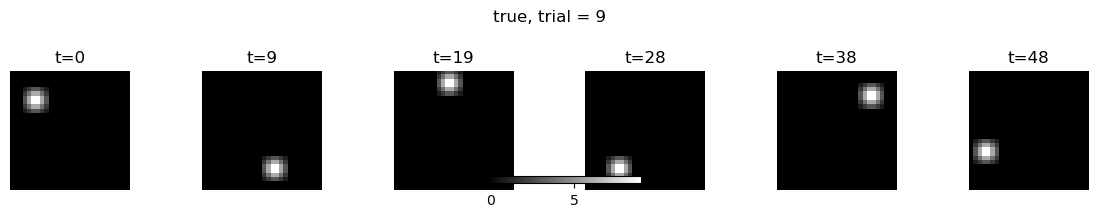

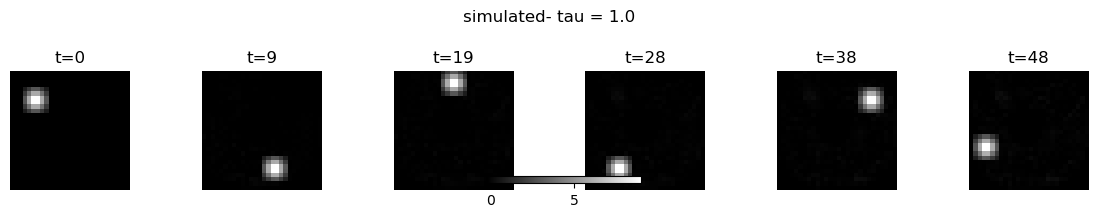

In [76]:
plot_tau(T, out_imgs_tau1, dset_samples, trial_idx = TRIAL_IDX, tau = 1.0)

/tmp/ipykernel_1681896/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_1681896/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


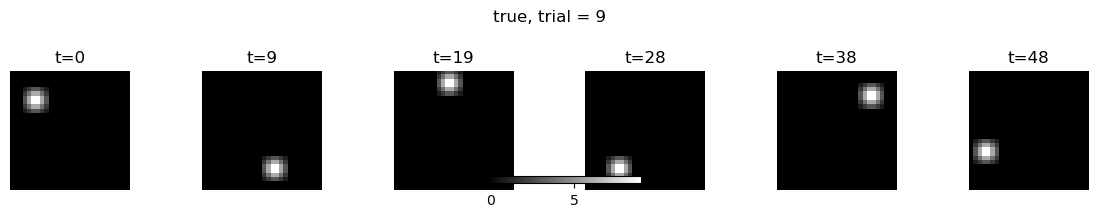

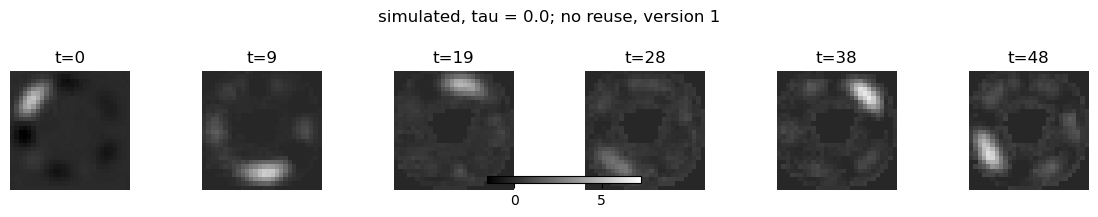

In [77]:
plot_tau(T, out_imgs_tau0, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0; no reuse, version 1')

In [79]:
# fig, axs = plt.subplots()
# norm  = Normalize(vmin=0, vmax=T_max)
# plot_latent_2d(axs, mu_traj_flow_np[TRIAL_IDX], norm, 'flowed, trial = ' + str(TRIAL_IDX))

In [80]:
# plot_latent_coordinate(mu_traj_flow_np[TRIAL_IDX], title = None, shrink_end = 0.30)
# plt.title('flowed, trial = ' + str(TRIAL_IDX))